In [1]:
# Install dependencies (Colab mein usually pre-installed hote hain, but sure karne ke liye)
!pip install -q xgboost shap imbalanced-learn

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

# Telco Customer Churn dataset - direct URL se load karo
url = "https://raw.githubusercontent.com/IBM/telco-customer-churn-on-icp4d/master/data/Telco-Customer-Churn.csv"
df = pd.read_csv(url)

print(df.shape)
df.head()

(7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [2]:
# TotalCharges column mein kuch blank values hote hain is dataset mein - clean karo
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df = df.dropna(subset=['TotalCharges'])

# customerID drop karo - modeling ke liye useless hai
df = df.drop('customerID', axis=1)

# Target variable check karo
print(df['Churn'].value_counts())
print(f"\nChurn rate: {df['Churn'].value_counts(normalize=True)['Yes']*100:.2f}%")

Churn
No     5163
Yes    1869
Name: count, dtype: int64

Churn rate: 26.58%


In [4]:
# Numeric summary - churn rate by key segments (business framing ke liye important)
print("Churn rate by Contract type:")
print(df.groupby('Contract')['Churn'].apply(lambda x: (x=='Yes').mean()*100).round(2))

print("\nChurn rate by Tenure group:")
print(df.groupby('tenure_group', observed=True)['Churn'].apply(lambda x: (x=='Yes').mean()*100).round(2))

print("\nChurn rate by Internet Service:")
print(df.groupby('InternetService')['Churn'].apply(lambda x: (x=='Yes').mean()*100).round(2))

Churn rate by Contract type:
Contract
Month-to-month    42.71
One year          11.28
Two year           2.85
Name: Churn, dtype: float64

Churn rate by Tenure group:
tenure_group
0-1yr    47.68
1-2yr    28.71
2-4yr    20.39
4-5yr    14.42
5-6yr     6.61
Name: Churn, dtype: float64

Churn rate by Internet Service:
InternetService
DSL            19.00
Fiber optic    41.89
No              7.43
Name: Churn, dtype: float64


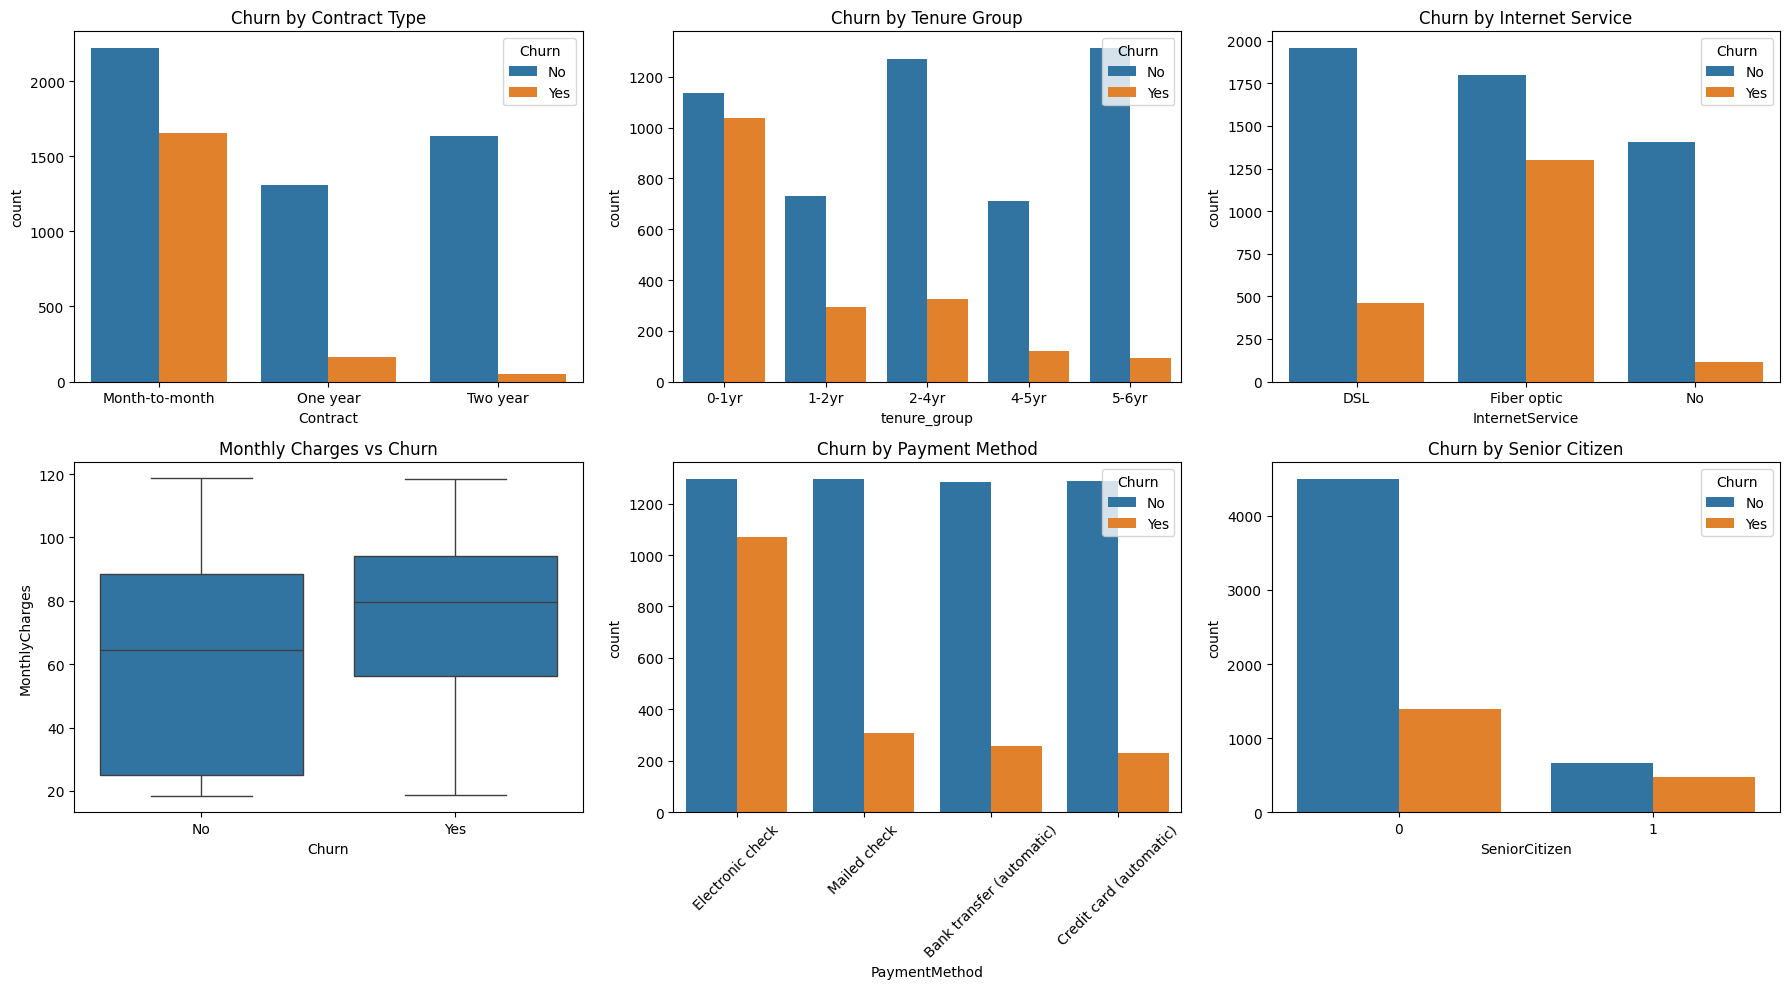

In [3]:
# Overall churn distribution visualize karo
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# 1. Churn by Contract type
sns.countplot(data=df, x='Contract', hue='Churn', ax=axes[0,0])
axes[0,0].set_title('Churn by Contract Type')

# 2. Churn by tenure (binned)
df['tenure_group'] = pd.cut(df['tenure'], bins=[0,12,24,48,60,72], labels=['0-1yr','1-2yr','2-4yr','4-5yr','5-6yr'])
sns.countplot(data=df, x='tenure_group', hue='Churn', ax=axes[0,1])
axes[0,1].set_title('Churn by Tenure Group')

# 3. Churn by InternetService
sns.countplot(data=df, x='InternetService', hue='Churn', ax=axes[0,2])
axes[0,2].set_title('Churn by Internet Service')

# 4. Monthly Charges distribution by churn
sns.boxplot(data=df, x='Churn', y='MonthlyCharges', ax=axes[1,0])
axes[1,0].set_title('Monthly Charges vs Churn')

# 5. Churn by PaymentMethod
sns.countplot(data=df, x='PaymentMethod', hue='Churn', ax=axes[1,1])
axes[1,1].set_title('Churn by Payment Method')
axes[1,1].tick_params(axis='x', rotation=45)

# 6. Churn by SeniorCitizen
sns.countplot(data=df, x='SeniorCitizen', hue='Churn', ax=axes[1,2])
axes[1,2].set_title('Churn by Senior Citizen')

plt.tight_layout()
plt.show()

In [5]:
from sklearn.preprocessing import LabelEncoder

# Binary columns encode karo (Yes/No -> 1/0)
binary_cols = ['Partner', 'Dependents', 'PhoneService', 'PaperlessBilling', 'Churn']
for col in binary_cols:
    df[col] = df[col].map({'Yes': 1, 'No': 0})

# gender encode karo
df['gender'] = df['gender'].map({'Male': 1, 'Female': 0})

# tenure_group drop karo (already tenure numeric hai, ye sirf EDA ke liye tha)
df = df.drop('tenure_group', axis=1)

# Multi-category columns ko one-hot encode karo
categorical_cols = ['MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup',
                     'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies',
                     'Contract', 'PaymentMethod']
df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

print(df_encoded.shape)
print(df_encoded.dtypes.value_counts())

(7032, 31)
bool       21
int64       8
float64     2
Name: count, dtype: int64


In [6]:
# Features aur target separate karo
X = df_encoded.drop('Churn', axis=1)
y = df_encoded['Churn']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train shape: {X_train.shape}, Test shape: {X_test.shape}")
print(f"Train churn rate: {y_train.mean()*100:.2f}%, Test churn rate: {y_test.mean()*100:.2f}%")

Train shape: (5625, 30), Test shape: (1407, 30)
Train churn rate: 26.58%, Test churn rate: 26.58%


In [7]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

# Scaling numeric features ke liye zaroori hai Logistic Regression mein
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

log_reg = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)
log_reg.fit(X_train_scaled, y_train)

y_pred_lr = log_reg.predict(X_test_scaled)
y_prob_lr = log_reg.predict_proba(X_test_scaled)[:, 1]

print("Logistic Regression Results:")
print(classification_report(y_test, y_pred_lr))
print(f"ROC-AUC: {roc_auc_score(y_test, y_prob_lr):.4f}")

Logistic Regression Results:
              precision    recall  f1-score   support

           0       0.91      0.70      0.79      1033
           1       0.49      0.80      0.61       374

    accuracy                           0.73      1407
   macro avg       0.70      0.75      0.70      1407
weighted avg       0.79      0.73      0.74      1407

ROC-AUC: 0.8350


In [8]:
from xgboost import XGBClassifier

# scale_pos_weight = negative class count / positive class count (imbalance handle karne ke liye)
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
print(f"Scale pos weight: {scale_pos_weight:.2f}")

xgb_model = XGBClassifier(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.05,
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    eval_metric='logloss'
)

xgb_model.fit(X_train, y_train)  # XGBoost ko scaling ki zaroorat nahi

y_pred_xgb = xgb_model.predict(X_test)
y_prob_xgb = xgb_model.predict_proba(X_test)[:, 1]

print("XGBoost Results:")
print(classification_report(y_test, y_pred_xgb))
print(f"ROC-AUC: {roc_auc_score(y_test, y_prob_xgb):.4f}")

Scale pos weight: 2.76
XGBoost Results:
              precision    recall  f1-score   support

           0       0.90      0.71      0.79      1033
           1       0.49      0.79      0.61       374

    accuracy                           0.73      1407
   macro avg       0.70      0.75      0.70      1407
weighted avg       0.79      0.73      0.74      1407

ROC-AUC: 0.8376


In [9]:
comparison = pd.DataFrame({
    'Model': ['Logistic Regression', 'XGBoost'],
    'ROC-AUC': [roc_auc_score(y_test, y_prob_lr), roc_auc_score(y_test, y_prob_xgb)],
    'Recall (Churn)': [
        classification_report(y_test, y_pred_lr, output_dict=True)['1']['recall'],
        classification_report(y_test, y_pred_xgb, output_dict=True)['1']['recall']
    ],
    'Precision (Churn)': [
        classification_report(y_test, y_pred_lr, output_dict=True)['1']['precision'],
        classification_report(y_test, y_pred_xgb, output_dict=True)['1']['precision']
    ]
})
print(comparison.round(4))

                 Model  ROC-AUC  Recall (Churn)  Precision (Churn)
0  Logistic Regression   0.8350          0.7968             0.4909
1              XGBoost   0.8376          0.7888             0.4941


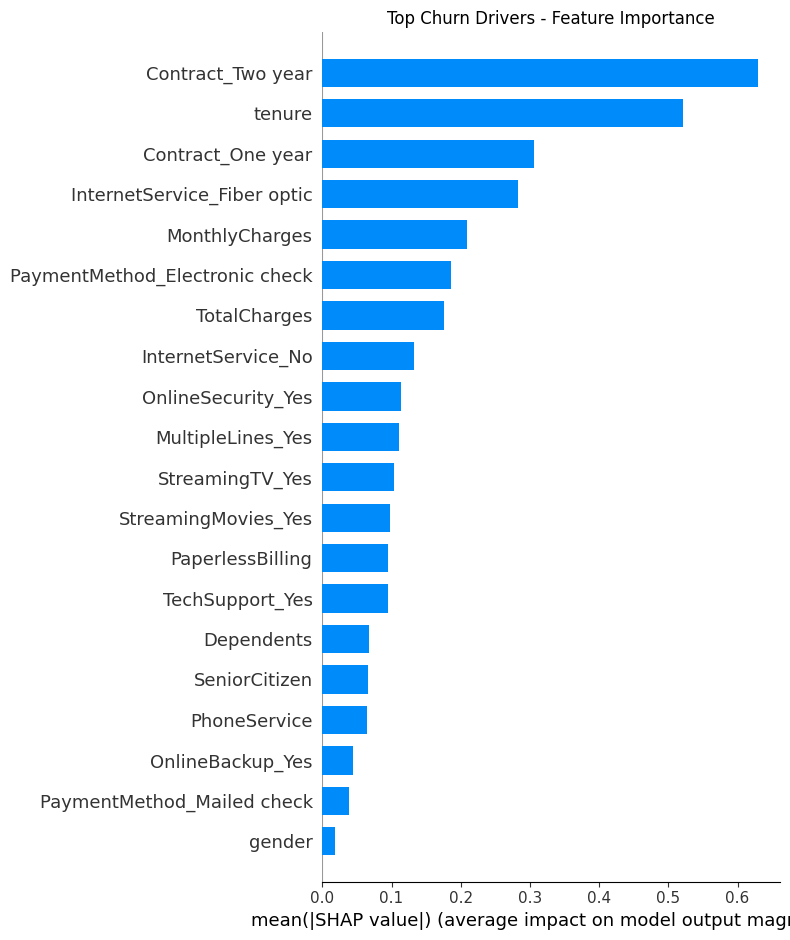

In [10]:
import shap

# XGBoost ke liye SHAP explainer (TreeExplainer fast hai tree-based models ke liye)
explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_test)

# Summary plot - overall feature importance
shap.summary_plot(shap_values, X_test, plot_type="bar", show=False)
plt.title("Top Churn Drivers - Feature Importance")
plt.tight_layout()
plt.savefig('shap_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

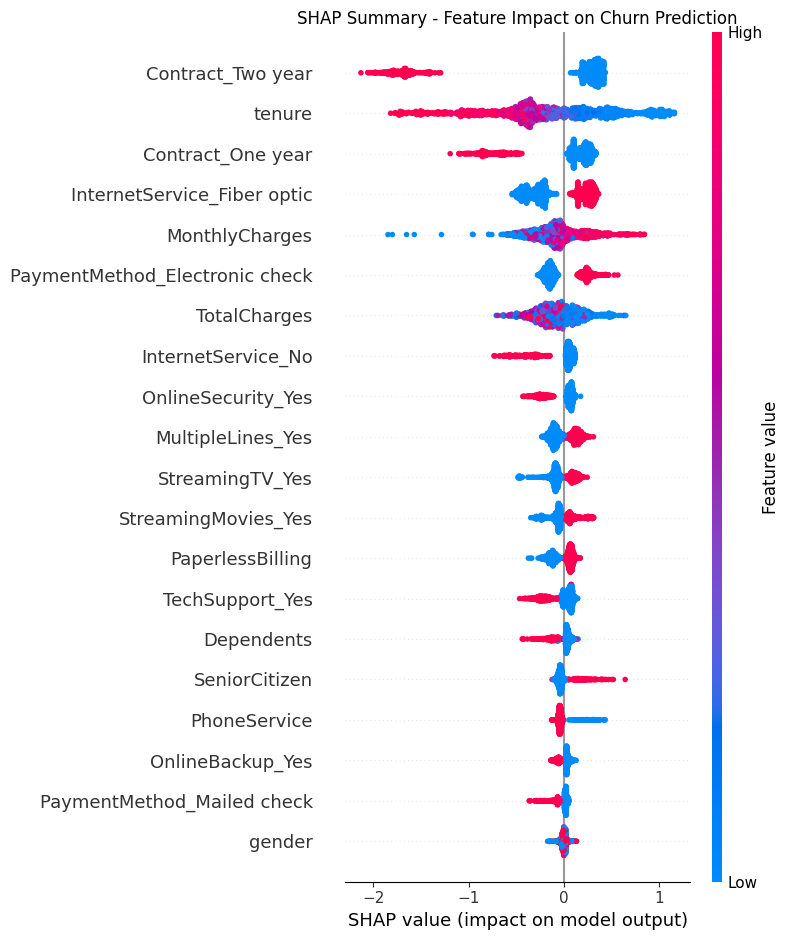

In [13]:
# Detailed summary plot - direction of impact bhi dikhata hai (red=high value, blue=low value)
shap.summary_plot(shap_values, X_test, show=False)
plt.title("SHAP Summary - Feature Impact on Churn Prediction")
plt.tight_layout()
plt.savefig('shap_summary.png', dpi=150, bbox_inches='tight')
plt.show()

In [14]:
# Top 5 features nikaalo numerically - business write-up ke liye
feature_importance = pd.DataFrame({
    'feature': X_test.columns,
    'mean_abs_shap': np.abs(shap_values).mean(axis=0)
}).sort_values('mean_abs_shap', ascending=False)

print("Top 10 Churn Drivers:")
print(feature_importance.head(10))

Top 10 Churn Drivers:
                           feature  mean_abs_shap
26               Contract_Two year       0.629830
4                           tenure       0.521391
25               Contract_One year       0.306203
11     InternetService_Fiber optic       0.283372
7                   MonthlyCharges       0.209120
28  PaymentMethod_Electronic check       0.185525
8                     TotalCharges       0.175546
12              InternetService_No       0.131869
14              OnlineSecurity_Yes       0.113618
10               MultipleLines_Yes       0.110527


In [15]:
# Test set pe predicted churn probability use karke high-risk customers identify karo
results_df = X_test.copy()
results_df['actual_churn'] = y_test.values
results_df['churn_probability'] = y_prob_xgb
results_df['MonthlyCharges_orig'] = df.loc[X_test.index, 'MonthlyCharges']

# High-risk segment define karo (top 20% highest churn probability)
threshold = results_df['churn_probability'].quantile(0.80)
high_risk = results_df[results_df['churn_probability'] >= threshold]

print(f"High-risk customers (top 20%): {len(high_risk)}")
print(f"Actual churn rate in this segment: {high_risk['actual_churn'].mean()*100:.2f}%")
print(f"Overall test set churn rate: {results_df['actual_churn'].mean()*100:.2f}%")

# Revenue at risk agar ye sab churn kar jaayein
monthly_revenue_at_risk = high_risk['MonthlyCharges_orig'].sum()
annual_revenue_at_risk = monthly_revenue_at_risk * 12

print(f"\nMonthly revenue at risk (high-risk segment): ${monthly_revenue_at_risk:,.2f}")
print(f"Annual revenue at risk: ${annual_revenue_at_risk:,.2f}")

High-risk customers (top 20%): 282
Actual churn rate in this segment: 64.18%
Overall test set churn rate: 26.58%

Monthly revenue at risk (high-risk segment): $21,578.90
Annual revenue at risk: $258,946.80


In [16]:
# Retention campaign impact estimate - agar 30% high-risk customers retain kar liye
retention_success_rate = 0.30  # industry-typical assumption, conservative

actual_churners_in_high_risk = high_risk[high_risk['actual_churn'] == 1]
customers_saved = int(len(actual_churners_in_high_risk) * retention_success_rate)
monthly_revenue_saved = actual_churners_in_high_risk['MonthlyCharges_orig'].sum() * retention_success_rate
annual_revenue_saved = monthly_revenue_saved * 12

print(f"Actual churners within high-risk segment: {len(actual_churners_in_high_risk)}")
print(f"Estimated customers saved (30% retention success): {customers_saved}")
print(f"Estimated annual revenue saved: ${annual_revenue_saved:,.2f}")

Actual churners within high-risk segment: 181
Estimated customers saved (30% retention success): 54
Estimated annual revenue saved: $49,971.06


In [17]:
from sklearn.model_selection import cross_val_score, StratifiedKFold

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(xgb_model, X_train, y_train, cv=cv, scoring='roc_auc')
print(f"CV ROC-AUC: {cv_scores.mean():.4f} (+/- {cv_scores.std():.4f})")

CV ROC-AUC: 0.8470 (+/- 0.0031)


In [18]:
from sklearn.model_selection import RandomizedSearchCV

param_dist = {
    'max_depth': [3,4,5,6],
    'n_estimators': [100,200,300],
    'learning_rate': [0.01,0.05,0.1],
    'subsample': [0.7,0.8,0.9,1.0]
}
search = RandomizedSearchCV(xgb_model, param_dist, n_iter=20, scoring='roc_auc', cv=3, random_state=42, n_jobs=-1)
search.fit(X_train, y_train)
print("Best params:", search.best_params_)
print("Best CV ROC-AUC:", search.best_score_)

# Best model ko naya variable mein save karo, aage yahi use karenge
best_xgb = search.best_estimator_

Best params: {'subsample': 0.8, 'n_estimators': 100, 'max_depth': 3, 'learning_rate': 0.1}
Best CV ROC-AUC: 0.8482221848383774


In [19]:
# Tuned model ko test set pe evaluate karo
y_pred_best = best_xgb.predict(X_test)
y_prob_best = best_xgb.predict_proba(X_test)[:, 1]

print("Tuned XGBoost Results:")
print(classification_report(y_test, y_pred_best))
print(f"ROC-AUC: {roc_auc_score(y_test, y_prob_best):.4f}")

Tuned XGBoost Results:
              precision    recall  f1-score   support

           0       0.91      0.71      0.80      1033
           1       0.50      0.80      0.62       374

    accuracy                           0.73      1407
   macro avg       0.70      0.76      0.71      1407
weighted avg       0.80      0.73      0.75      1407

ROC-AUC: 0.8386


In [20]:
from sklearn.metrics import precision_recall_curve

precisions, recalls, thresholds = precision_recall_curve(y_test, y_prob_best)
# F2 score - recall ko zyada weight (churner miss karna costly hai retention offer dene se zyada)
f_beta = (1 + 2**2) * (precisions * recalls) / (2**2 * precisions + recalls + 1e-9)
optimal_idx = np.argmax(f_beta[:-1])
optimal_threshold = thresholds[optimal_idx]
print(f"Optimal threshold (F2-optimized): {optimal_threshold:.3f}")
print(f"At this threshold - Precision: {precisions[optimal_idx]:.3f}, Recall: {recalls[optimal_idx]:.3f}")

# Compare with default 0.5 threshold
print(f"\nAt default 0.5 threshold - Precision: {precisions[np.argmin(np.abs(thresholds-0.5))]:.3f}, Recall: {recalls[np.argmin(np.abs(thresholds-0.5))]:.3f}")

Optimal threshold (F2-optimized): 0.314
At this threshold - Precision: 0.443, Recall: 0.896

At default 0.5 threshold - Precision: 0.498, Recall: 0.805


In [21]:
n_bootstrap = 1000
boot_scores = []
y_test_arr = y_test.values
for _ in range(n_bootstrap):
    idx = np.random.choice(len(y_test_arr), len(y_test_arr), replace=True)
    boot_scores.append(roc_auc_score(y_test_arr[idx], y_prob_best[idx]))

print(f"Mean ROC-AUC: {np.mean(boot_scores):.4f}")
print(f"95% CI: [{np.percentile(boot_scores,2.5):.4f}, {np.percentile(boot_scores,97.5):.4f}]")

Mean ROC-AUC: 0.8382
95% CI: [0.8161, 0.8608]


In [22]:
results_df['churn_probability_tuned'] = y_prob_best
results_df['risk_tier'] = pd.cut(results_df['churn_probability_tuned'],
                                   bins=[0,0.3,0.6,1.0], labels=['Low','Medium','High'])

tier_summary = results_df.groupby('risk_tier', observed=True).agg(
    count=('actual_churn','count'),
    churn_rate=('actual_churn','mean'),
    avg_monthly_revenue=('MonthlyCharges_orig','mean'),
    total_monthly_revenue=('MonthlyCharges_orig','sum')
).round(3)

print(tier_summary)

           count  churn_rate  avg_monthly_revenue  total_monthly_revenue
risk_tier                                                               
Low          630       0.062               53.020               33402.65
Medium       283       0.226               69.987               19806.30
High         494       0.549               74.556               36830.90


In [23]:
# Tiered retention strategy - actionable recommendations
print("="*60)
print("RETENTION STRATEGY BY RISK TIER")
print("="*60)

print("""
HIGH RISK (54.9% churn rate, 494 customers, $36,830.90/month revenue)
→ Action: Personal outreach call + custom retention offer
→ Priority: Immediate (within 48 hours)
→ Rationale: Highest churn probability AND highest average revenue
   per customer ($74.56) - losing these customers has the biggest
   financial impact

MEDIUM RISK (22.6% churn rate, 283 customers, $19,806.30/month revenue)
→ Action: Automated discount email + engagement survey
→ Priority: Within 1-2 weeks
→ Rationale: Moderate risk, lower-touch intervention is cost-effective

LOW RISK (6.2% churn rate, 630 customers, $33,402.65/month revenue)
→ Action: No intervention needed - standard engagement only
→ Priority: Monitor quarterly
→ Rationale: Intervention cost would exceed expected benefit
""")

print(f"Total addressable revenue at risk (Medium + High): "
      f"${tier_summary.loc[['Medium','High'],'total_monthly_revenue'].sum()*12:,.2f} annually")

RETENTION STRATEGY BY RISK TIER

HIGH RISK (54.9% churn rate, 494 customers, $36,830.90/month revenue)
→ Action: Personal outreach call + custom retention offer
→ Priority: Immediate (within 48 hours)
→ Rationale: Highest churn probability AND highest average revenue 
   per customer ($74.56) - losing these customers has the biggest 
   financial impact

MEDIUM RISK (22.6% churn rate, 283 customers, $19,806.30/month revenue)
→ Action: Automated discount email + engagement survey
→ Priority: Within 1-2 weeks
→ Rationale: Moderate risk, lower-touch intervention is cost-effective

LOW RISK (6.2% churn rate, 630 customers, $33,402.65/month revenue)
→ Action: No intervention needed - standard engagement only
→ Priority: Monitor quarterly
→ Rationale: Intervention cost would exceed expected benefit

Total addressable revenue at risk (Medium + High): $679,646.40 annually
